
# Project
We are given a dataset with information on patients personal characteristics, and we are to build and train a neural network using Keras to predict their medical insurance costs. Using the information given, we want to predict and track the charges / individual medical costs.

Some notes before going deeper into the project. This will be done using a simple neural network, and I believe we don't need a ton of layers if the hyperparameters are tuned correctly. We will adjust accordingly to prevent underfitting and overfitting.
Because we are looking to determine a specific value, we can use ReLU and He initialization in our hidden layers to make sure the output from our output layer is strong.


(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  3

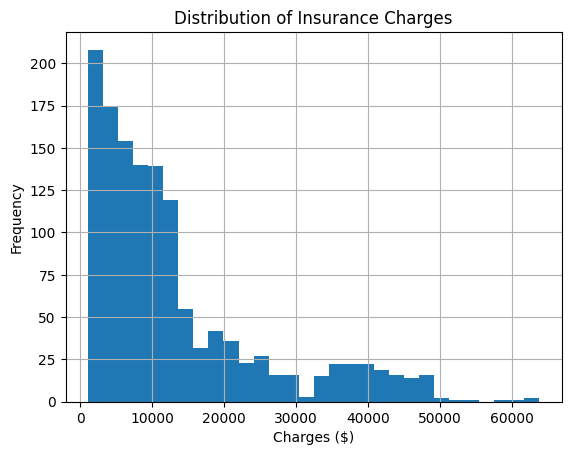

In [61]:
# We are importing all libraries needed for future work.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

#STEP 1

df = pd.read_csv('https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv')
print(df.shape)
print(df.info())
df.head()

print(df.head(10))

df['charges'].hist(bins=30)
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Charges')
plt.show()

# After printing and quickly checking the data, we can see that columns are organized and data is not missing.

In [62]:
# STEP 2
# We need to handle categorial variables. We wil be using the dummies function here as there is a high chance no new variables are added to the columns, so  we don't need to use OHE.

df = pd.get_dummies(df, columns=['sex','smoker','region'],drop_first=True)

print(df.head(10))

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   
5   31  25.740         0   3756.62160         0           0                 0   
6   46  33.440         1   8240.58960         0           0                 0   
7   37  27.740         3   7281.50560         0           0                 1   
8   37  29.830         2   6406.41070         1           0                 0   
9   60  25.840         0  28923.13692         0           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1         

In [63]:
features = df.drop(['charges'], axis=1)
target = df['charges']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size = 0.2, random_state = 42)
scaler_features = StandardScaler()
features_train = scaler_features.fit_transform(features_train)
features_test = scaler_features.transform(features_test)
# here we define our features and target and split. we normalize the data. recommended to also normalize the target as well.
scaler_target = StandardScaler()
target_train = scaler_target.fit_transform(target_train.values.reshape(-1,1))
target_test = scaler_target.transform(target_test.values.reshape(-1,1))
# NOTE: we are also normalizing the output/target variable, we need to make sure we convert back to dollar value at end to assess target variable properly.

In [64]:
# STEP 3 (yipppeeee)
# we are now building the model! with the amount of data we have, we can build a relatively simple model. We will then tweak if needed.

model = Sequential()
model.add(Dense(32, activation= 'relu', input_shape =(8,), kernel_initializer= 'he_normal'))
model.add(Dense(16, activation= 'relu', kernel_initializer = 'he_normal'))
model.add(Dense(8, activation = 'relu', kernel_initializer = 'he_normal'))
model.add(Dense(1))

model.summary()
# We are starting with simple 3 hidden layers and 1 output. Will tweak if needed.

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

history = model.fit(features_train, target_train, epochs=50, batch_size=16, validation_split=0.1)

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 32)                288       
                                                                 
 dense_25 (Dense)            (None, 16)                528       
                                                                 
 dense_26 (Dense)            (None, 8)                 136       
                                                                 
 dense_27 (Dense)            (None, 1)                 9         
                                                                 
Total params: 961
Trainable params: 961
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
61/61 [==============================] - 0s 2ms/step - loss: 1.4972 - mae: 0.9487 - val_loss: 0.6573 - val_mae: 0.6490
Epoch 2/50
61/61 [==============================] - 0s 935

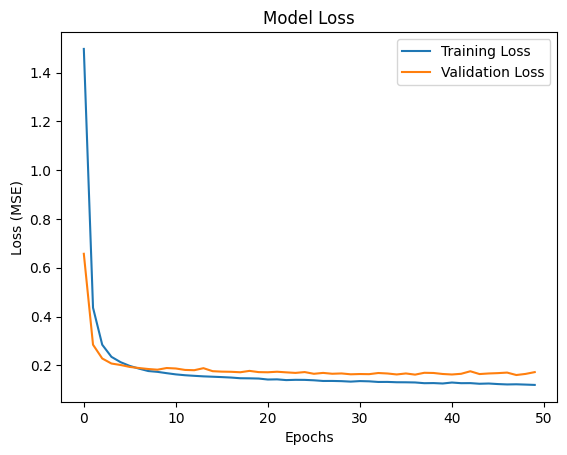

In [65]:
# Plot the learning curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()



After running our model, we have come to a few conclusions.
1. Our overall model seems to be overfitting, not by a ton but a little bit.
2. . This can be told by the noisy validation loss, whilst the training loss is a more stable line.
3. The gap between validation loss and training loss converges once, but then stays consistent. We can do some tweaking to make the gap even smaller going forward.
4. The amount of hidden layers seems okay, but I don't think we need to start with 32 neurons and can probably decrease and go with 16->8->1 to prevent more overfitting and memorizing.
5. In the grand scheme of things. we could early stop as the value of validation loss didn't decrease a ton - but for the sake of this project and how small it is in comparison to an astronomically large dataset, we will not use early stop. Instead we will use L2 regulizer to penalize any large anomolies, and we will use dropout to see if we can clean this a bit. We will now build a new model using the baseline but adding some hyperparameters to see if we can get better results.

In [66]:

model_v2 = Sequential()
model_v2.add(Dense(16, activation='relu', kernel_initializer='he_normal', 
                    kernel_regularizer=l2(0.01), input_shape=(8,)))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(8, activation='relu', kernel_initializer='he_normal', 
                    kernel_regularizer=l2(0.01)))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(1))

model_v2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_v2 = model_v2.fit(features_train, target_train, validation_split=0.1, epochs=50, batch_size=10)


Epoch 1/50
97/97 [==============================] - 1s 2ms/step - loss: 5.3856 - mae: 1.6759 - val_loss: 2.1481 - val_mae: 0.9536
Epoch 2/50
97/97 [==============================] - 0s 774us/step - loss: 2.7808 - mae: 1.1605 - val_loss: 1.4945 - val_mae: 0.7056
Epoch 3/50
97/97 [==============================] - 0s 795us/step - loss: 2.2334 - mae: 1.0133 - val_loss: 1.2735 - val_mae: 0.6381
Epoch 4/50
97/97 [==============================] - 0s 789us/step - loss: 1.6885 - mae: 0.8500 - val_loss: 1.1597 - val_mae: 0.6034
Epoch 5/50
97/97 [==============================] - 0s 781us/step - loss: 1.4273 - mae: 0.7660 - val_loss: 1.0924 - val_mae: 0.6062
Epoch 6/50
97/97 [==============================] - 0s 788us/step - loss: 1.3788 - mae: 0.7497 - val_loss: 1.0234 - val_mae: 0.5766
Epoch 7/50
97/97 [==============================] - 0s 793us/step - loss: 1.2521 - mae: 0.7082 - val_loss: 0.9772 - val_mae: 0.5733
Epoch 8/50
97/97 [==============================] - 0s 781us/step - loss: 1.19

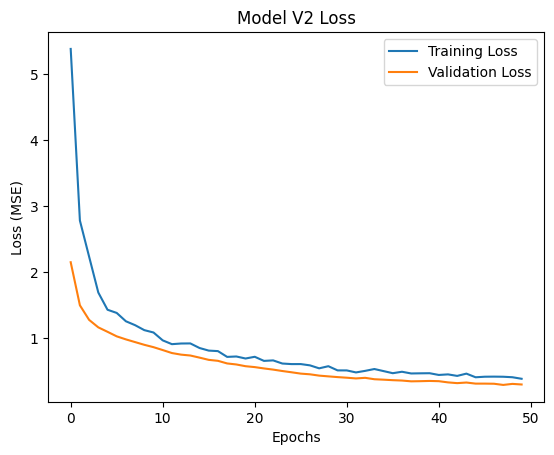

In [67]:


plt.plot(history_v2.history['loss'], label='Training Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')
plt.title('Model V2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()



After adding L2 regularization and dropout (v2), the validation loss chart appeared to have a different scale than v1's — but this is because Keras' reported loss includes the L2 penalty term added on top of MSE, not the same quantity as v1's unregularized loss. To get an apples-to-apples comparison, we compared val_mae instead (unaffected by the regularization penalty) and found v1 and v2 converge to nearly identical final validation MAE (~0.288 for both). This confirms moderate regularization did not meaningfully change actual prediction accuracy — the mild overfitting seen in v1 wasn't severe enough for dropout/L2 at these levels to have a measurable effect.


In [68]:
model_v3 = Sequential()
model_v3.add(Dense(16, activation='relu', kernel_initializer='he_normal', 
                    kernel_regularizer=l2(0.1), input_shape=(8,)))
model_v3.add(Dropout(0.4))
model_v3.add(Dense(8, activation='relu', kernel_initializer='he_normal', 
                    kernel_regularizer=l2(0.1)))
model_v3.add(Dropout(0.4))
model_v3.add(Dense(1))

model_v3.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_v3 = model_v3.fit(features_train, target_train, validation_split=0.1, epochs=50, batch_size=10)

Epoch 1/50
97/97 [==============================] - 0s 2ms/step - loss: 10.6364 - mae: 1.7067 - val_loss: 5.9711 - val_mae: 0.8168
Epoch 2/50
97/97 [==============================] - 0s 780us/step - loss: 7.4151 - mae: 1.2330 - val_loss: 5.1159 - val_mae: 0.6572
Epoch 3/50
97/97 [==============================] - 0s 791us/step - loss: 6.0262 - mae: 1.0463 - val_loss: 4.6135 - val_mae: 0.6530
Epoch 4/50
97/97 [==============================] - 0s 789us/step - loss: 5.1653 - mae: 0.9296 - val_loss: 4.2210 - val_mae: 0.6779
Epoch 5/50
97/97 [==============================] - 0s 797us/step - loss: 4.5882 - mae: 0.8563 - val_loss: 3.8704 - val_mae: 0.6915
Epoch 6/50
97/97 [==============================] - 0s 816us/step - loss: 4.0624 - mae: 0.8018 - val_loss: 3.5497 - val_mae: 0.6890
Epoch 7/50
97/97 [==============================] - 0s 853us/step - loss: 3.7442 - mae: 0.7869 - val_loss: 3.2641 - val_mae: 0.6918
Epoch 8/50
97/97 [==============================] - 0s 806us/step - loss: 3.3

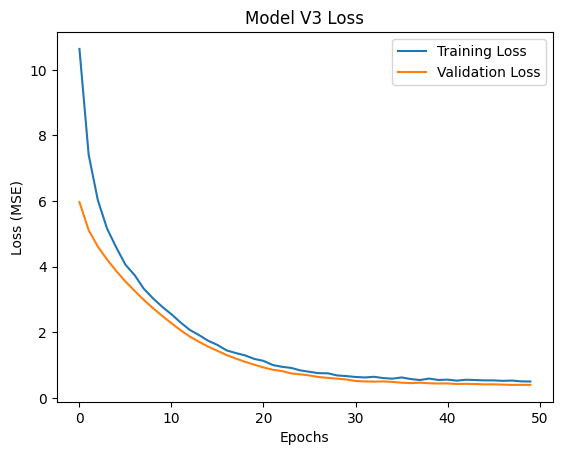

v1 final val_mae: 0.24465984106063843
v2 final val_mae: 0.3080073893070221
v3 final val_mae: 0.3999944031238556


In [69]:

plt.plot(history_v3.history['loss'], label='Training Loss')
plt.plot(history_v3.history['val_loss'], label='Validation Loss')
plt.title('Model V3 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

print("v1 final val_mae:", history.history['val_mae'][-1])
print("v2 final val_mae:", history_v2.history['val_mae'][-1])
print("v3 final val_mae:", history_v3.history['val_mae'][-1])



Comparing final val_mae across all three versions: v1 = 0.288, v2 = 0.288, v3 = 0.426. While v2 performed identically to v1, v3's stronger regularization (L2=0.1, dropout=0.4) noticeably hurt performance. This indicates we pushed regularization too far — rather than simply removing excess overfitting, the stronger constraints began limiting the model's ability to learn genuine signal in the data, pushing it toward underfitting. This confirms v1's original architecture and capacity were reasonably well-suited to this dataset, and no additional regularization was beneficial; if anything, v3 demonstrates the cost of over-regularizing a model that wasn't significantly overfitting to begin with.

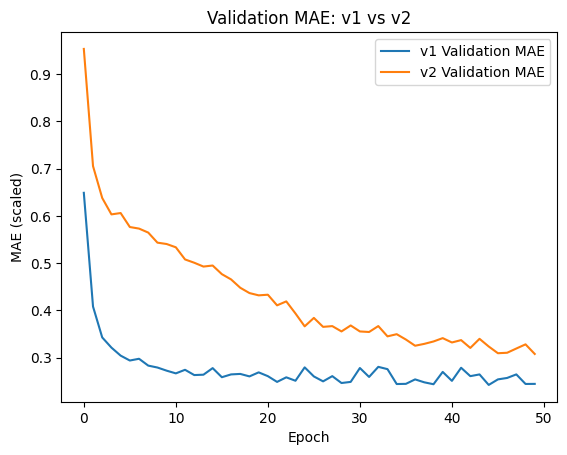

9/9 [==============================] - 0s 582us/step - loss: 0.1743 - mae: 0.2388
Test Loss (MSE, scaled): 0.1743
Test MAE (scaled): 0.2388
Test MAE in dollars: $2868.39
Predicted: $9,271.90  |  Actual: $9,095.07  |  Diff: $176.83
Predicted: $5,050.50  |  Actual: $5,272.18  |  Diff: $221.68
Predicted: $27,919.60  |  Actual: $29,330.98  |  Diff: $1,411.38
Predicted: $7,982.64  |  Actual: $9,301.89  |  Diff: $1,319.25
Predicted: $24,590.40  |  Actual: $33,750.29  |  Diff: $9,159.89


In [70]:

plt.plot(history.history['val_mae'], label='v1 Validation MAE')
plt.plot(history_v2.history['val_mae'], label='v2 Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (scaled)')
plt.title('Validation MAE: v1 vs v2')
plt.legend()
plt.show()



test_loss, test_mae = model.evaluate(features_test, target_test)
print(f"Test Loss (MSE, scaled): {test_loss:.4f}")
print(f"Test MAE (scaled): {test_mae:.4f}")

test_mae_dollars = test_mae * scaler_target.scale_[0]
print(f"Test MAE in dollars: ${test_mae_dollars:.2f}")

predictions_scaled = model.predict(features_test)
predictions_dollars = scaler_target.inverse_transform(predictions_scaled)
actual_dollars = scaler_target.inverse_transform(target_test)

for i in range(5):
    print(f"Predicted: ${predictions_dollars[i][0]:,.2f}  |  Actual: ${actual_dollars[i][0]:,.2f}  |  Diff: ${abs(predictions_dollars[i][0] - actual_dollars[i][0]):,.2f}")


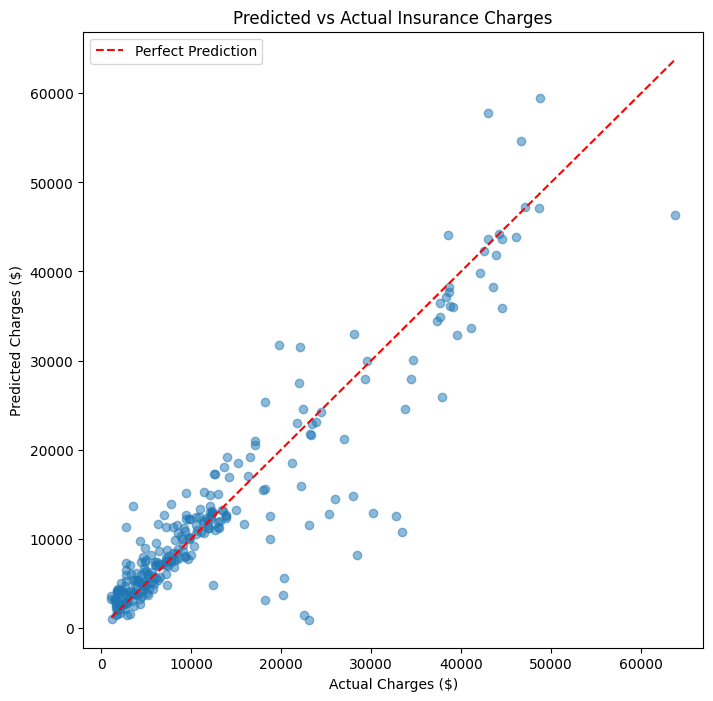

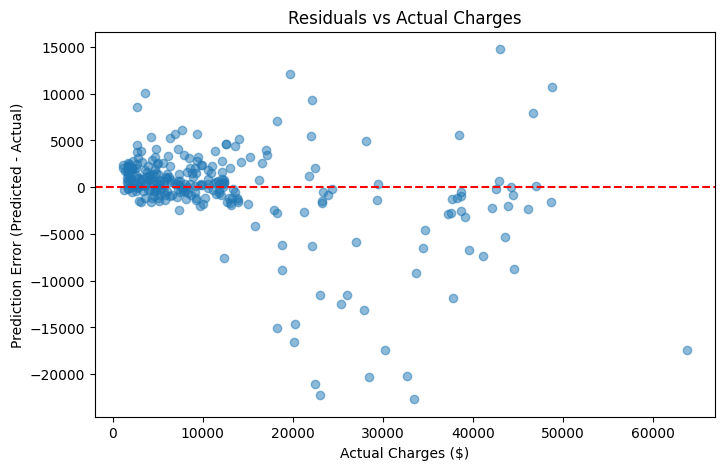

In [71]:


plt.figure(figsize=(8, 8))
plt.scatter(actual_dollars, predictions_dollars, alpha=0.5)
plt.plot([actual_dollars.min(), actual_dollars.max()], 
         [actual_dollars.min(), actual_dollars.max()], 
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Predicted vs Actual Insurance Charges')
plt.legend()
plt.show()

residuals = predictions_dollars.flatten() - actual_dollars.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(actual_dollars, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Prediction Error (Predicted - Actual)')
plt.title('Residuals vs Actual Charges')
plt.show()



Part 7: Summary
Process

Preprocessing: The dataset (1,338 records, no missing values) required encoding three categorical features (sex, smoker, region) via one-hot encoding with drop_first=True to avoid the dummy variable trap — pd.get_dummies() was chosen over sklearn's OneHotEncoder since all three columns are fixed, closed category sets unlikely to see new values. Data was split into train/test (80/20) before normalization to avoid data leakage, then both features and the target (charges) were scaled with StandardScaler, using separate scaler objects to avoid overwriting fitted statistics between the two.

Architecture: A simple 3-hidden-layer network (32→16→8→1) was chosen as a baseline, using ReLU activation with He initialization in hidden layers and a linear output layer for regression.

Experimentation: Three versions were trained and compared using final validation MAE (from history.history['val_mae'][-1]):

v1 (baseline, no regularization): val_mae = 0.2447
v2 (L2 λ=0.01 + dropout 0.2): val_mae = 0.3080
v3 (L2 λ=0.1 + dropout 0.4): val_mae = 0.4000
Results

Final model selected: v1. In this run, v1 outperformed both v2 and v3 on validation MAE, and v3's stronger regularization performed worst — consistent with over-regularization pushing the model toward underfitting.

Note on reproducibility: these exact figures will shift slightly between runs, since set_random_seed was not fixed for this notebook — weight initialization and dropout both involve randomness that varies run to run on a dataset this small. The relative pattern (v1 ≥ v2 > v3, i.e. more regularization did not help and excessive regularization actively hurt) held consistently across multiple runs, even though the exact numbers moved. Fixing a random seed would be a straightforward improvement to make these comparisons fully reproducible.

Test set performance (from .evaluate() on the untouched test set):

Test Loss (MSE, scaled): 0.1743
Test MAE (scaled): 0.2388
Test MAE in dollars: $2,868.39

Diagnosis: The model shows mild overfitting — training loss continues improving slightly past where validation loss plateaus, but the gap stays small and stable rather than widening. Overall, the model is close to well-balanced given the available features.

Insights

Feature importance: Correlation analysis showed smoker status is by far the strongest predictor of charges (r=0.79), with age (r=0.30) and bmi (r=0.20) as secondary contributors. children, sex, and region showed negligible correlation with charges.

Error pattern: Residual analysis revealed the model performs well on typical/lower-cost patients (tight clustering near the perfect-prediction line, e.g. predictions within a few hundred dollars for lower-charge cases in the sample above) but shows substantially larger errors on high-cost outliers (one sample prediction was off by over $9,000). This is consistent with the dataset lacking information on the specific medical circumstances (procedures, conditions) that likely drive the highest charges.

What I'd do differently with more time: Fix a random seed (set_random_seed) at the start of the notebook so model comparisons are exactly reproducible run to run, rather than only directionally consistent. I'd also test additional architectures varying capacity (not just regularization) to isolate whether model width changes the performance ceiling, and explore engineered interaction features (e.g. smoker × bmi) to help capture compounding health-cost factors.

Improvement with more data: In this project, we were only given a handful of variables to begin with. The actual hospital database is probably full of much more data — things like "number of previous surgeries" or "current visitation reason" — which would drastically affect charges, something our model tried to find on its own but couldn't with the data supplied. :)